In [20]:
from matminer.datasets import load_dataset
import pandas as pd
import numpy as np

In [21]:
df = load_dataset("expt_gap")
df.head()

,formula,gap expt
0,Hg0.7Cd0.3Te,0.35
1,CuBr,3.08
2,LuP,1.30
3,Cu3SbSe4,0.40
4,ZnO,3.44


In [22]:
print(df.shape)

(6354, 2)


In [23]:
print(df.columns)

Index(['formula', 'gap expt'], dtype='object')


In [24]:
comp_col = "formula"
target_col = "gap expt"

df_model = df[[comp_col, target_col]].dropna().copy()
df_model.head()

,formula,gap expt
0,Hg0.7Cd0.3Te,0.35
1,CuBr,3.08
2,LuP,1.30
3,Cu3SbSe4,0.40
4,ZnO,3.44


In [25]:
df_model

,formula,gap expt
0,Hg0.7Cd0.3Te,0.35
1,CuBr,3.08
2,LuP,1.30
3,Cu3SbSe4,0.40
4,ZnO,3.44
...,...,...
6349,Tm2MgTl,0.00
6350,Nb5Ga4,0.00
6351,Tb2Sb5,0.00
6352,Lu2AlTc,0.00


In [26]:
from pymatgen.core import Composition

In [27]:
def composition_features(formula):

    comp = Composition(str(formula))
    elems = comp.fractional_composition.get_el_amt_dict()

    atomic_numbers = []
    weights = []

    for el, amt in elems.items():
        atomic_numbers.append(Composition(el).elements[0].Z)
        weights.append(amt)

    atomic_numbers = np.array(atomic_numbers, dtype=float)
    weights = np.array(weights, dtype=float)

    return pd.Series({
        "n_elements": len(elems),
        "mean_Z": np.average(atomic_numbers, weights=weights),
        "max_Z": np.max(atomic_numbers),
        "min_Z": np.min(atomic_numbers)
    })

In [28]:
X_df = df_model[comp_col].apply(composition_features)

y = df_model[target_col].values

X_df.head()

,n_elements,mean_Z,max_Z,min_Z
0,3.0,61.20,80.0,48.0
1,2.0,32.00,35.0,29.0
2,2.0,43.00,71.0,15.0
3,3.0,34.25,51.0,29.0
4,2.0,19.00,30.0,8.0


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [31]:
pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.49436855231225574
R2: 0.6226352980989366


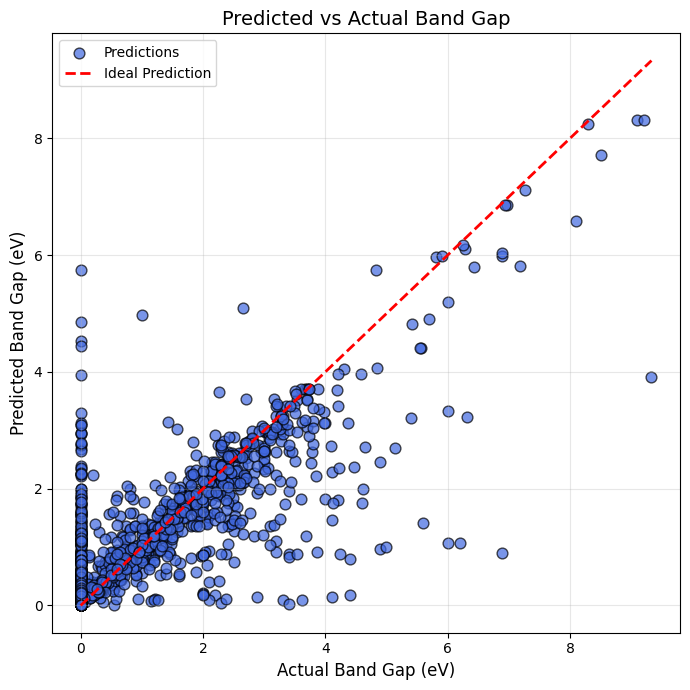

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ensure figures folder exists
os.makedirs("figures", exist_ok=True)

y_test_plot = np.array(y_test, dtype=float)
pred_plot = np.array(pred, dtype=float)

plt.figure(figsize=(7,7))

# scatter plot
plt.scatter(
    y_test_plot,
    pred_plot,
    color="royalblue",
    alpha=0.7,
    edgecolors="black",
    s=60,
    label="Predictions"
)

# diagonal ideal prediction line
min_val = min(y_test_plot.min(), pred_plot.min())
max_val = max(y_test_plot.max(), pred_plot.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Band Gap (eV)", fontsize=12)
plt.ylabel("Predicted Band Gap (eV)", fontsize=12)

plt.title("Predicted vs Actual Band Gap", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig("figures/pred_vs_actual.png", dpi=300)

plt.show()

In [37]:
df.to_csv("data/expt_gap.csv", index=False)

results = pd.DataFrame({
    "actual": y_test,
    "predicted": pred
})

results.to_csv("data/predictions.csv", index=False)